In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import random
from tqdm import tqdm
import zipfile
import os
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage import exposure, filters, morphology
from skimage.measure import label
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## Dataset Path

In [4]:
DATA_PATH = Path('/kaggle/input/competitions/data-science-bowl-2018')  

# Verify data exists
print(f"\nData path exists: {DATA_PATH.exists()}")


Data path exists: True


In [11]:
print("Extracting dataset...")
DATA_PATH = Path('/kaggle/input/competitions/data-science-bowl-2018')
WORK_DIR = Path('/kaggle/working/dsb2018')
WORK_DIR.mkdir(exist_ok=True)

train_zip = DATA_PATH / 'stage1_train.zip'
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall(WORK_DIR)
print("Extraction complete")

Extracting dataset...
Extraction complete


In [12]:
# Find training path
train_path = WORK_DIR / 'stage1_train'
if not train_path.exists():
    train_path = WORK_DIR

# Get all image IDs
all_image_ids = [d.name for d in train_path.iterdir() if d.is_dir()]
print(f"Found {len(all_image_ids)} training images\n")


example_id = all_image_ids[0]
example_folder = train_path / example_id
mask_files = list((example_folder / 'masks').glob('*.png'))

print(f"Example: {example_id}")
print(f"  - Images: {len(list((example_folder / 'images').glob('*.png')))} file")
print(f"  - Masks: {len(mask_files)} nuclei")
print(f"  - Mask values: 0=background, {cv2.imread(str(mask_files[0]), cv2.IMREAD_GRAYSCALE).max()}=nucleus\n")


Found 670 training images

Example: a1777737270c5f96c4523dff76e4097756f8f7d4c9d59bac079e31f9510deabd
  - Images: 1 file
  - Masks: 26 nuclei
  - Mask values: 0=background, 255=nucleus



Creating visualization...
saved dataset_samples.png


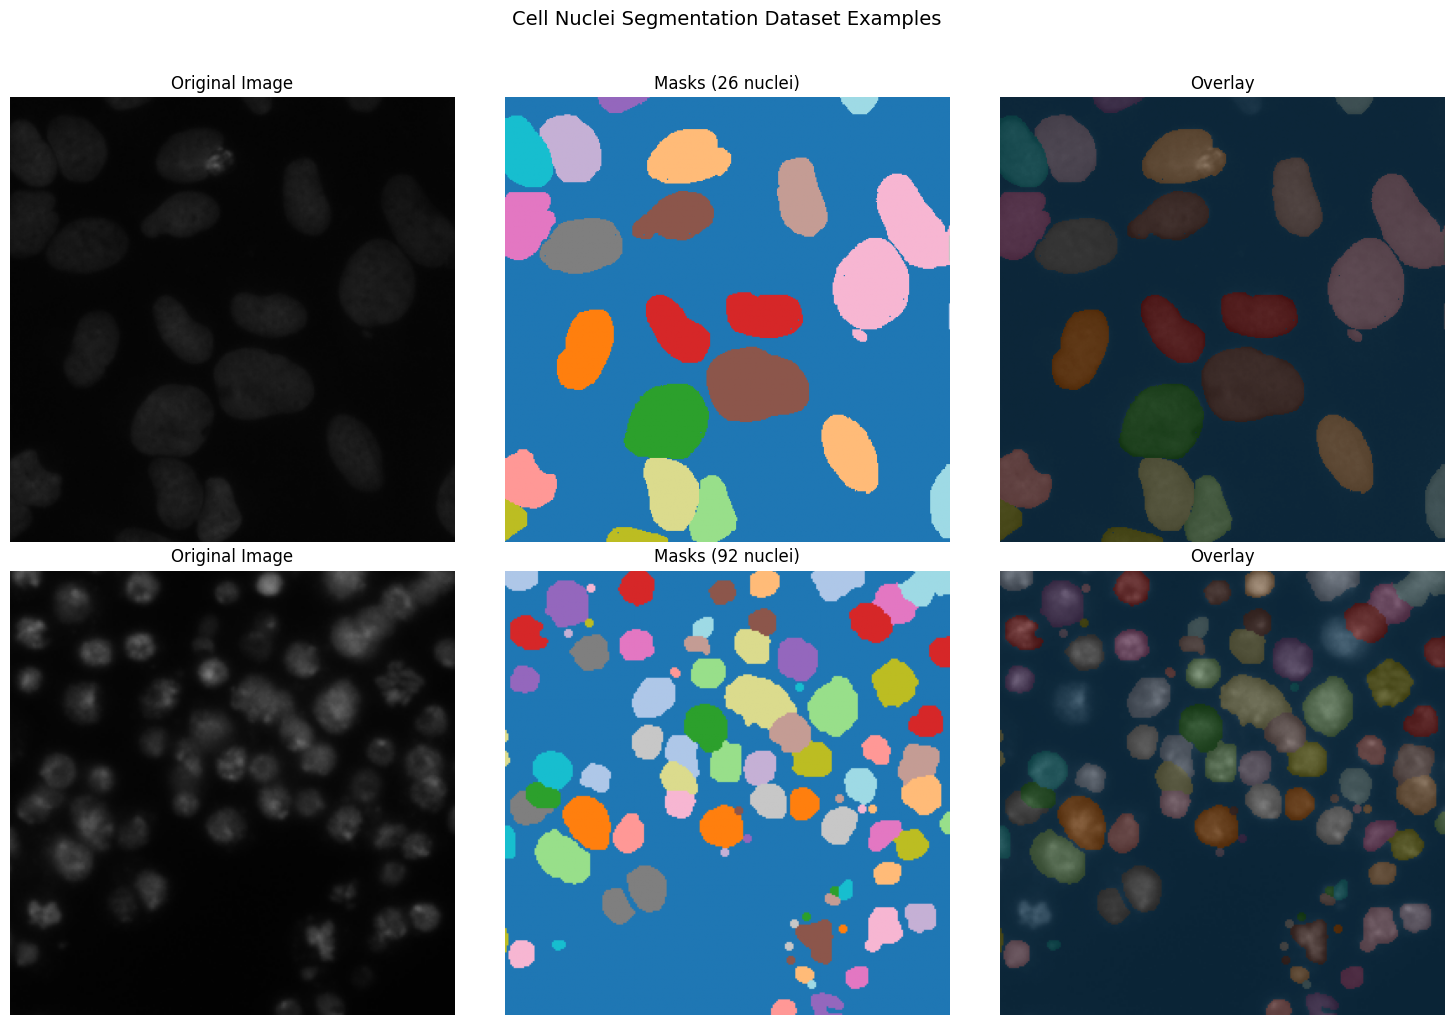

In [13]:


# STEP 3: Visualize 2 examples and save

print("Creating visualization...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx in range(2):
    img_id = all_image_ids[idx]
    
    # Load image
    img_path = train_path / img_id / 'images' / f'{img_id}.png'
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Combine masks
    masks_path = train_path / img_id / 'masks'
    mask_files = list(masks_path.glob('*.png'))
    combined_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.int32)
    
    for i, mask_file in enumerate(mask_files, start=1):
        single_mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
        single_mask = (single_mask > 0)
        combined_mask[single_mask] = i
    
    # Display
    axes[idx, 0].imshow(image)
    axes[idx, 0].set_title(f'Original Image', fontsize=12)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(combined_mask, cmap='tab20')
    axes[idx, 1].set_title(f'Masks ({len(mask_files)} nuclei)', fontsize=12)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(image)
    axes[idx, 2].imshow(combined_mask, cmap='tab20', alpha=0.3)
    axes[idx, 2].set_title('Overlay', fontsize=12)
    axes[idx, 2].axis('off')

plt.suptitle('Cell Nuclei Segmentation Dataset Examples', fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig('/kaggle/working/dataset_samples.png', dpi=150, bbox_inches='tight')
print("saved dataset_samples.png")
plt.show()



Analyzing dataset statistics...


100%|██████████| 50/50 [00:00<00:00, 312.68it/s]


Saved: dataset_distributions.png


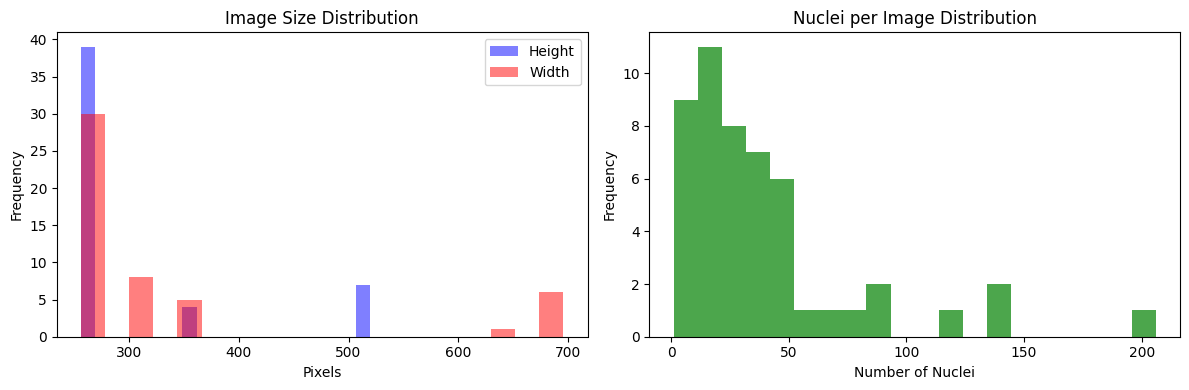

DATASET SUMMARY
Total training images: 670
Image sizes: 256x256 to 520x696
Median image size: 256x256
Nuclei per image - Min: 1, Max: 206
Nuclei per image - Mean: 38.8, Median: 27
Saved: dataset_stats.json


In [14]:

# STEP 4: Calculate statistics and SAVE

print("\nAnalyzing dataset statistics...")
image_heights = []
image_widths = []
nuclei_counts = []

for img_id in tqdm(all_image_ids[:50]):
    img_path = train_path / img_id / 'images' / f'{img_id}.png'
    image = cv2.imread(str(img_path))
    h, w = image.shape[:2]
    image_heights.append(h)
    image_widths.append(w)
    
    masks_path = train_path / img_id / 'masks'
    nuclei_counts.append(len(list(masks_path.glob('*.png'))))


# STEP 5: Plot distributions and SAVE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(image_heights, bins=20, alpha=0.5, label='Height', color='blue')
ax1.hist(image_widths, bins=20, alpha=0.5, label='Width', color='red')
ax1.set_xlabel('Pixels')
ax1.set_ylabel('Frequency')
ax1.set_title('Image Size Distribution')
ax1.legend()

ax2.hist(nuclei_counts, bins=20, color='green', alpha=0.7)
ax2.set_xlabel('Number of Nuclei')
ax2.set_ylabel('Frequency')
ax2.set_title('Nuclei per Image Distribution')

plt.tight_layout()

# SAVE FIGURE 2
plt.savefig('/kaggle/working/dataset_distributions.png', dpi=150, bbox_inches='tight')
print("Saved: dataset_distributions.png")
plt.show()

# STEP 6: Print summary

print("DATASET SUMMARY")

print(f"Total training images: {len(all_image_ids)}")
print(f"Image sizes: {min(image_heights)}x{min(image_widths)} to {max(image_heights)}x{max(image_widths)}")
print(f"Median image size: {int(np.median(image_heights))}x{int(np.median(image_widths))}")
print(f"Nuclei per image - Min: {min(nuclei_counts)}, Max: {max(nuclei_counts)}")
print(f"Nuclei per image - Mean: {np.mean(nuclei_counts):.1f}, Median: {np.median(nuclei_counts):.0f}")
print("="*50)


# STEP 7: Save statistics as JSON for report

import json

stats = {
    "total_images": len(all_image_ids),
    "image_height_range": [min(image_heights), max(image_heights)],
    "image_width_range": [min(image_widths), max(image_widths)],
    "median_height": int(np.median(image_heights)),
    "median_width": int(np.median(image_widths)),
    "nuclei_per_image": {
        "min": min(nuclei_counts),
        "max": max(nuclei_counts),
        "mean": round(np.mean(nuclei_counts), 1),
        "median": int(np.median(nuclei_counts))
    }
}

with open('/kaggle/working/dataset_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print("Saved: dataset_stats.json")


In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Use 80% for training, 20% for validation
train_ids, val_ids = train_test_split(
    all_image_ids, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Total images: {len(all_image_ids)}")
print(f"Training images: {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")

Total images: 670
Training images: 536
Validation images: 134


In [16]:
# Training augmentations (helps prevent overfitting)
train_augmentations = A.Compose([
    A.Resize(256, 256),  # Resize all images to 256x256
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
    ToTensorV2(),
])

# Validation augmentations (only resize + normalize, no random transforms)
val_augmentations = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("Training augmentations defined")
print("Validation augmentations defined")


Training augmentations defined
Validation augmentations defined


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [18]:
class NucleiDataset(Dataset):
    """Dataset for cell nuclei segmentation"""
    
    def __init__(self, image_ids, train_path, augmentations):
        self.image_ids = image_ids
        self.train_path = train_path
        self.augmentations = augmentations
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        
        # Load image
        img_path = self.train_path / img_id / 'images' / f'{img_id}.png'
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load and combine masks
        masks_path = self.train_path / img_id / 'masks'
        mask_files = list(masks_path.glob('*.png'))
        
        # Create single mask (0=background, 1,2,3...=different nuclei)
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
        for i, mask_file in enumerate(mask_files, start=1):
            single_mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
            single_mask = (single_mask > 0).astype(np.float32)
            mask[single_mask == 1] = i
        
        # Convert to binary mask (1 = nucleus, 0 = background)
        # For U-Net, we use binary segmentation
        binary_mask = (mask > 0).astype(np.float32)
        
        # Apply augmentations
        if self.augmentations:
            augmented = self.augmentations(image=image, mask=binary_mask)
            image = augmented['image']
            mask = augmented['mask']
        
        return image, mask.unsqueeze(0)  # Add channel dimension: [1, H, W]


In [19]:

# STEP 4: Create DataLoaders

print("\n" + "="*40)
print("STEP 4: Creating DataLoaders")
print("="*40)

# Create datasets
train_dataset = NucleiDataset(train_ids, train_path, train_augmentations)
val_dataset = NucleiDataset(val_ids, train_path, val_augmentations)


BATCH_SIZE = 8  

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train loader: {len(train_loader)} batches of size {BATCH_SIZE}")
print(f"Val loader: {len(val_loader)} batches of size {BATCH_SIZE}")


STEP 4: Creating DataLoaders
Train loader: 67 batches of size 8
Val loader: 17 batches of size 8


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Image value range: [-2.12, 2.64]
Mask value range: [0.0, 1.0]


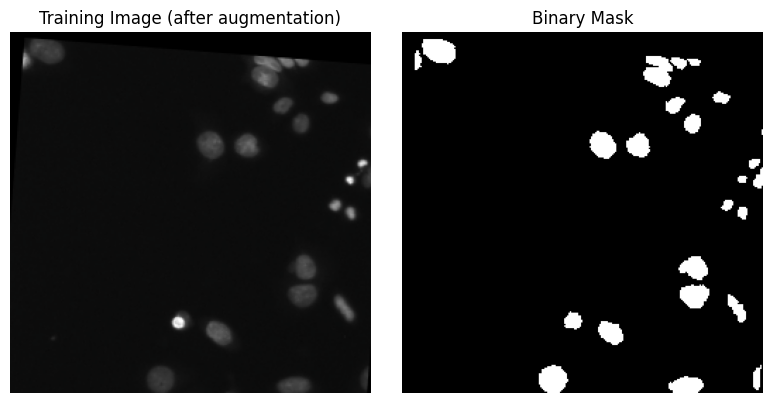


Saved: dataloader_sample.png


In [20]:

# STEP 5: Test the dataloader

# Load one batch to verify
sample_images, sample_masks = next(iter(train_loader))
print(f"Image batch shape: {sample_images.shape}")  # [batch, channels, height, width]
print(f"Mask batch shape: {sample_masks.shape}")    # [batch, 1, height, width]
print(f"Image value range: [{sample_images.min():.2f}, {sample_images.max():.2f}]")
print(f"Mask value range: [{sample_masks.min()}, {sample_masks.max()}]")

# Visualize one sample
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Denormalize image for display
img_display = sample_images[0].permute(1, 2, 0).numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

ax1.imshow(img_display)
ax1.set_title('Training Image (after augmentation)')
ax1.axis('off')

ax2.imshow(sample_masks[0, 0].numpy(), cmap='gray')
ax2.set_title('Binary Mask')
ax2.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/dataloader_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: dataloader_sample.png")

In [21]:

# ============================================
# STEP 6: Save for next notebook

import pickle

data_info = {
    'train_ids': train_ids,
    'val_ids': val_ids,
    'train_path': str(train_path),
    'num_train': len(train_ids),
    'num_val': len(val_ids),
    'batch_size': BATCH_SIZE,
    'image_size': 256
}

with open('/kaggle/working/data_info.pkl', 'wb') as f:
    pickle.dump(data_info, f)

print("✓ Saved: data_info.pkl")
print("\nCell 3 Complete!")
print("Files saved:")
print("   - dataloader_sample.png")
print("   - data_info.pkl")

✓ Saved: data_info.pkl

Cell 3 Complete!
Files saved:
   - dataloader_sample.png
   - data_info.pkl
